In [23]:
using CSV
using DataFrames
using DelimitedFiles
using CairoMakie
using LsqFit

In [2]:
messung = readdlm(raw"C:\Users\fynnd\OneDrive\Documents\Uni\Praktikum\Praktikum_B\Festkoerperphysik\Ferroelektrische_Ordnung\Daten\24_06_26\C_T", '\t', Float64; comments=true, skipblanks=true)



1465×2 Matrix{Float64}:
 323.145  1.71304e-10
 323.146  1.71303e-10
 323.147  1.71293e-10
 323.144  1.7129e-10
 323.149  1.71282e-10
 323.15   1.71267e-10
 323.154  1.7125e-10
 323.152  1.71243e-10
 323.148  1.71232e-10
 323.153  1.71223e-10
 323.146  1.7121e-10
 323.145  1.71205e-10
 323.148  1.712e-10
   ⋮      
 310.917  1.85902e-10
 310.911  1.85689e-10
 310.907  1.85464e-10
 310.896  1.8525e-10
 310.888  1.8504e-10
 310.877  1.84818e-10
 310.877  1.84599e-10
 310.867  1.84387e-10
 310.865  1.84177e-10
 310.863  1.83972e-10
 310.85   1.83757e-10
 310.835  1.83547e-10

In [11]:
T = messung[:,1]
C_x = messung[:,2];
T


1465-element Vector{Float64}:
 323.144837
 323.146452
 323.147108
 323.143769
 323.149222
 323.150086
 323.154472
 323.151711
 323.147701
 323.1527
 323.145871
 323.14535
 323.1476
   ⋮
 310.916637
 310.910516
 310.907208
 310.89563
 310.888315
 310.876881
 310.877486
 310.866578
 310.864599
 310.863448
 310.850076
 310.83536

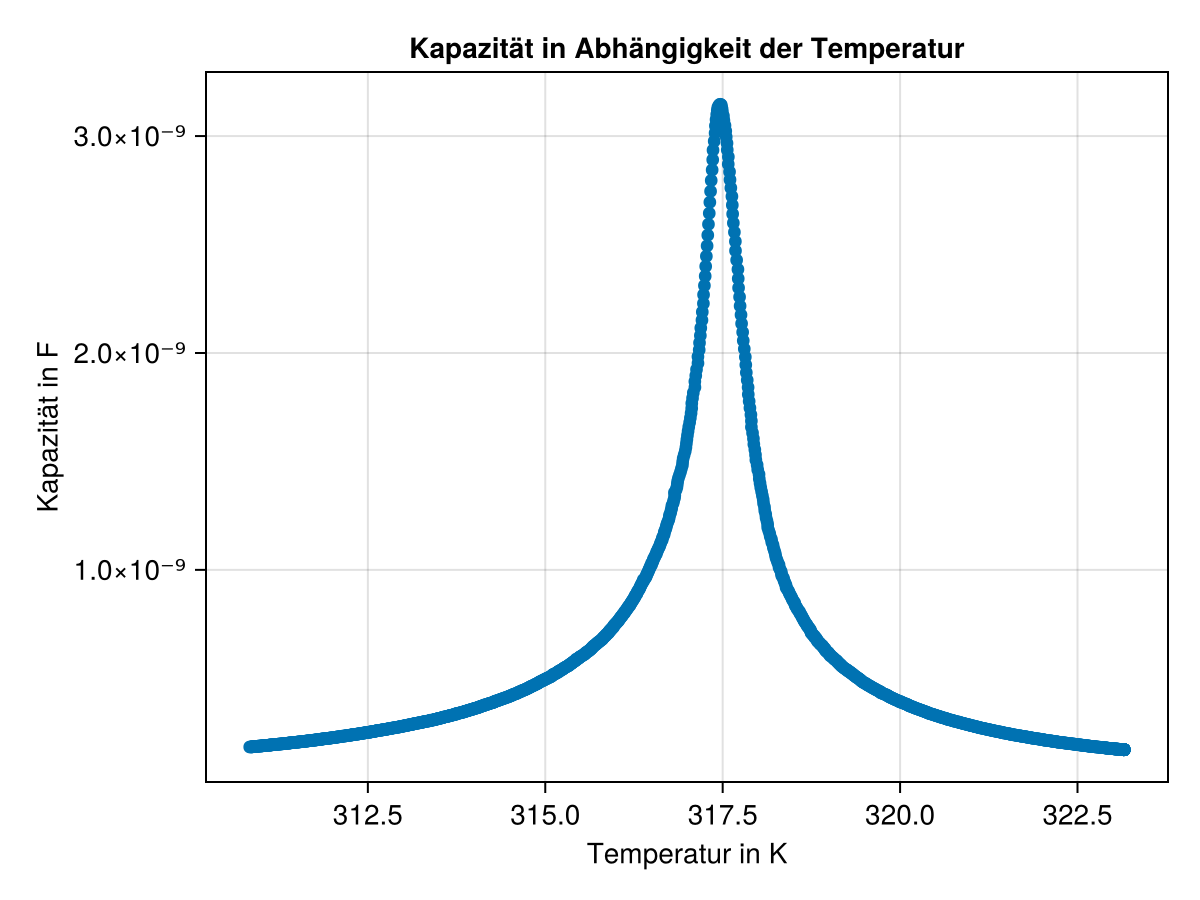

In [6]:
fig1 = Figure()
ax = Axis(fig1[1,1],title = "Kapazität in Abhängigkeit der Temperatur" ,xlabel = "Temperatur in K", ylabel = "Kapazität in F")
scatter!(ax, T, C_x)

fig1

In [ ]:
save("Kapazitä_vs_Temp.pdf", fig1)

CairoMakie.Screen{PDF}


In [7]:
#Berechnung von ϵ 
d = 10^(-3)
Δd = 0.1e-3
A = 45e-6  
ΔA = 3*10^(-3)
ϵ0 = 8.854e-12 #F/m


ϵ = C_x .*(d/(A*ϵ0))

1465-element Vector{Float64}:
 429.9475441106343
 429.9450342594684
 429.9199357478102
 429.9124061943127
 429.89232738498606
 429.8546796174987
 429.8120121476797
 429.79444318951886
 429.76683482669483
 429.7442461662024
 429.7116181010466
 429.69906884521754
 429.68651958938835
   ⋮
 466.58635142936026
 466.05175313103933
 465.48703661872855
 464.9499284692418
 464.42285972441834
 463.86567276560504
 463.31601536028916
 462.78392691313405
 462.25685816831066
 461.74233867931633
 461.20272067866375
 460.67565193384036

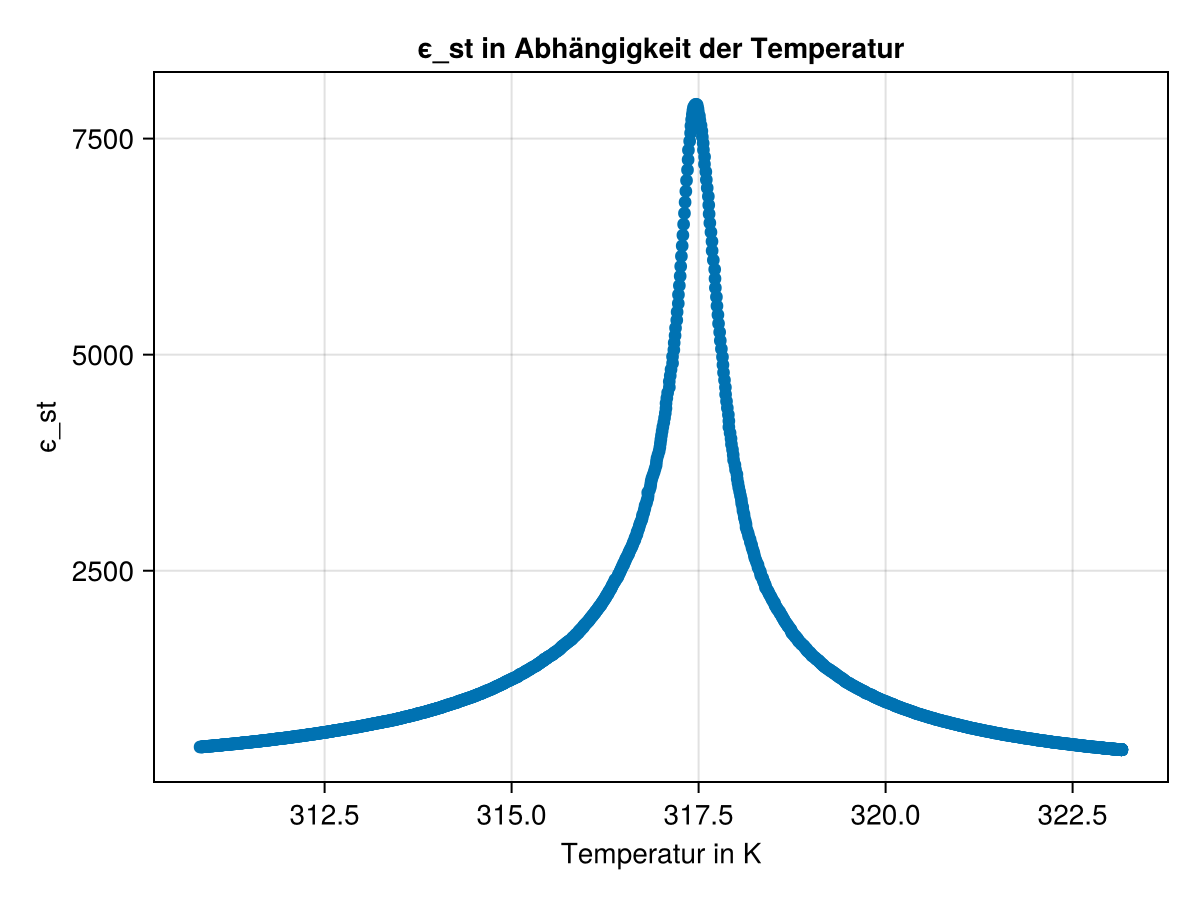

In [21]:
fig2 = Figure()
ax = Axis(fig2[1,1],title = "ϵ_st in Abhängigkeit der Temperatur", xlabel = "Temperatur in K", ylabel = "ϵ_st")
scatter!(ax, T, ϵ)
fig2

In [23]:
save("statisch_epsilon_vs_t.pdf", fig2)

CairoMakie.Screen{PDF}


In [8]:
#i/epsilon und dann in einem bereich einen fit

ϵ_inv = 1 ./ϵ 

1465-element Vector{Float64}:
 0.0023258651286601597
 0.0023258787061522564
 0.0023260144897923438
 0.0023260552279759468
 0.0023261638701089432
 0.0023263676014643802
 0.0023265985401459853
 0.002326693645871656
 0.0023268431134367403
 0.0023269654193653886
 0.0023271421061853864
 0.002327210069799363
 0.0023272780373831776
 ⋮
 0.002143226000796118
 0.002145684450882928
 0.002148287538282362
 0.002150769230769231
 0.0021532101167315177
 0.002155796513326624
 0.0021583540539222854
 0.002160835633748583
 0.0021632994347828447
 0.0021657099993477266
 0.0021682439308434508
 0.0021707246645273418

In [55]:
fig3 = Figure()
ax = Axis(fig3[1,1], xlabel = "Temperatur in K", ylabel = "1/ϵ_st")
scatter!(ax, T, ϵ_inv)
fig3
save("epsilon_inv.pdf", fig3)

CairoMakie.Screen{PDF}


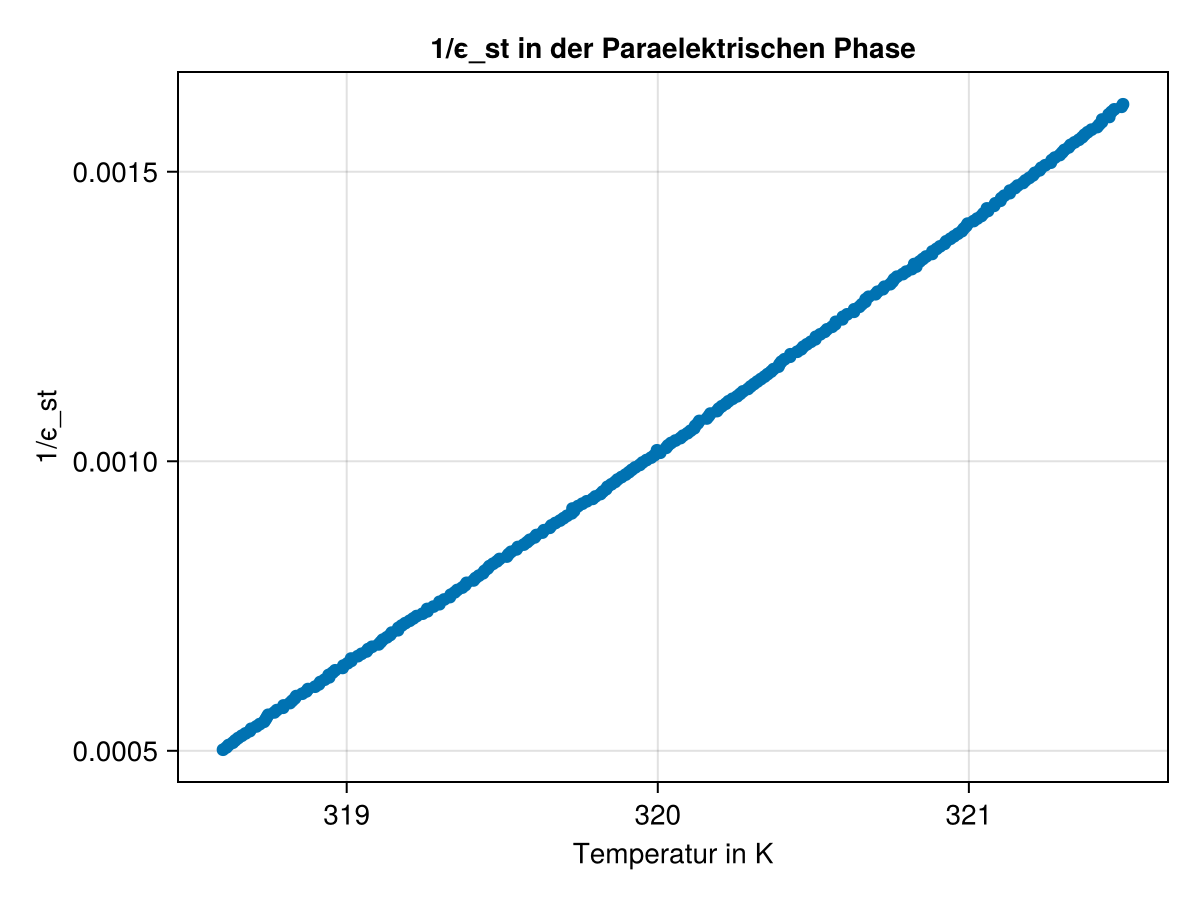

In [48]:
#Werte anpassen s.d. nur Werte ab 317.5 vorkommen bis zu einem max Wert

T_min = 318.6
T_max = 321.5

mask = (T .>T_min) .& (T .< T_max)

T_para = T[mask]
y_para = ϵ_inv[mask]

#In para phase plotten
fig5 = Figure()
ax = Axis(fig5[1,1], title = "1/ϵ_st in der Paraelektrischen Phase" ,xlabel = "Temperatur in K", ylabel = "1/ϵ_st")
scatter!(ax, T_para, y_para)
fig5

In [53]:
save("epsilon_inv_para.pdf", fig5)

CairoMakie.Screen{PDF}


In [49]:
#Fit der Geraden
#funktion des Fits defenieren y=m*x+b
@. gerade(x, p) = p[1]*x + p[2]

#Startewerte
p0 = [0.00039, 0.0] 

fit = curve_fit(gerade, T_para, y_para, p0)

#m und b geben lassen
m, b = fit.param
Δm, Δb = stderror(fit)

println("Steigung m = $m ± $Δm")
println("y-Abschnitt b =$b ± $Δb")

Steigung m = 0.0003820655319211393 ± 6.102126811250665e-7
y-Abschnitt b =-0.1212355167335187 ± 0.00019530730805230375


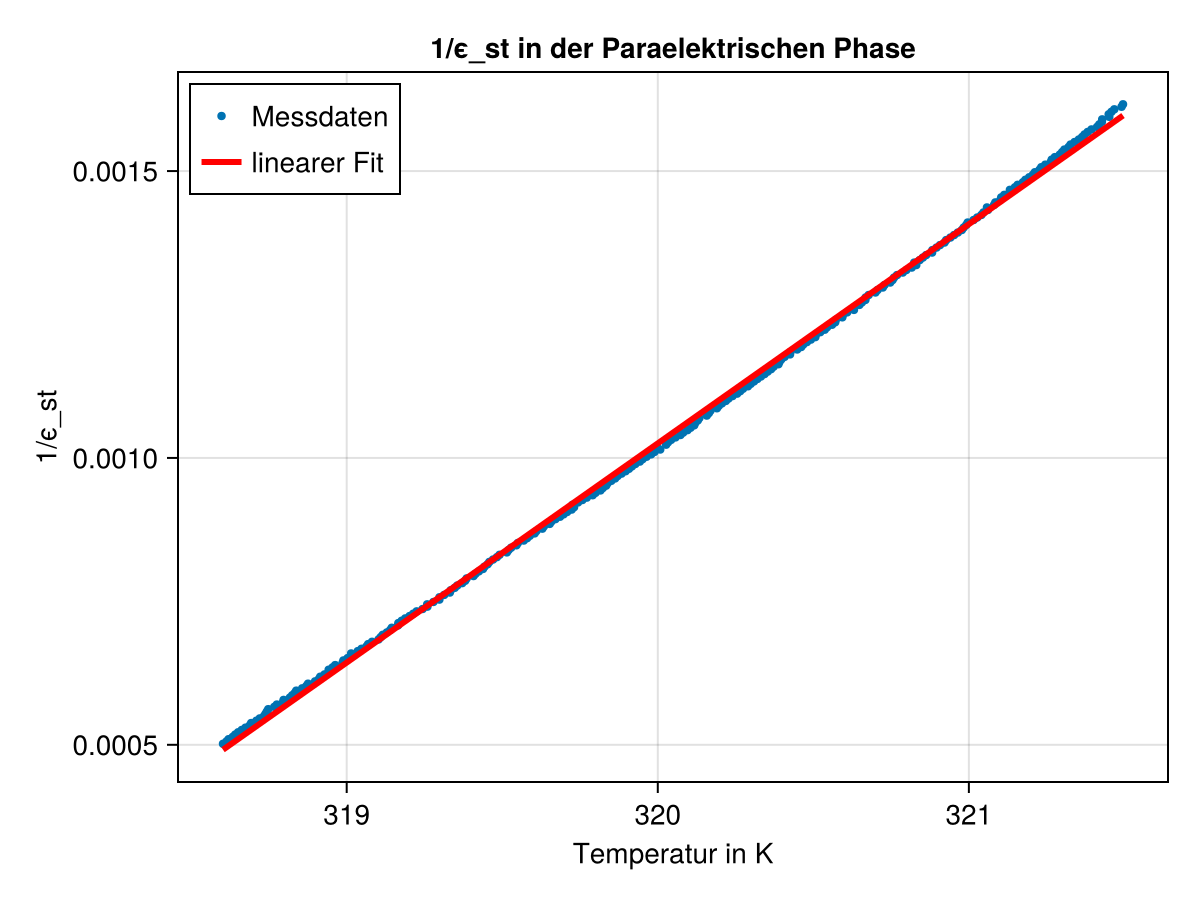

In [52]:
#Fit über Messwerte Plotten lassen

fig4 = Figure()
ax = Axis(fig4[1,1], title = "1/ϵ_st in der Paraelektrischen Phase" ,xlabel = "Temperatur in K", ylabel = "1/ϵ_st")


scatter!(ax, T_para, y_para, label = "Messdaten", markersize = 6)

#
T_fit = range(minimum(T_para), maximum(T_para), length = 100)
y_fit = gerade(T_fit, fit.param)

lines!(ax, T_fit, y_fit, label = "linearer Fit", color = :red, linewidth = 3)

axislegend(ax, position = :lt)


fig4

In [54]:
save("epsilon_inv_fit.pdf", fig4)

CairoMakie.Screen{PDF}
